# Library

In [35]:

import sys
sys.path.append("/project/assistant")

# %load_ext autoreload
# # re-imports the package on every cell run, so edits to the .py files apply without restarting the kernel
# %autoreload 2 

import pandas as pd
import frontmatter

import os
import re
from pathlib import Path

from tqdm import tqdm

from datetime import datetime, timezone
from dataclasses import dataclass, field
from pathlib import Path
from urllib.parse import unquote
import matplotlib.pyplot as plt
import numpy as np
import time

from elasticsearch import Elasticsearch
from sentence_transformers import SentenceTransformer

import re
from collections import Counter
from pathlib import Path
from urllib.parse import unquote

# Project structure

This notebook runs on the Jupyter service of the stack, so its view of the
filesystem is the container's view, not the host's. Three paths matter.

``/project`` is the whole repository, bind mounted into the container. The
notebook lives in ``/project/notebooks``, so that is the kernel's working
directory, and a plain ls shows the repo folders. Anything I edit here is
instantly the same file on the host, because a mount is one folder seen
from two sides, not a copy.

``/vault`` is a second, separate mount: the Obsidian vault, mounted read only
at the root of the container's filesystem. It does not appear inside
/project because it is a neighbor, not a child. Read only is deliberate,
the assistant reads notes and can never touch them.

The code always uses absolute paths (``/project/assistant`` for imports,
``/vault`` for notes) instead of relative ones. Relative paths depend on where
the kernel happens to be standing; absolute paths make every cell work the
same no matter where the notebook lives or moves.


In [36]:
!pwd

/project


In [37]:
!ls

Dockerfile  assistant	docker-compose.gpu.yml	notebooks
Makefile    data	docker-compose.yml	requirements.txt
README.md   demo_vault	grafana			setup.sh


In [38]:
!ls /vault/llm-zoomcamp-2026/01-agentic-rag

01-intro-agentic-rag.md  07-llm.md	       13-function-calling.md
02-environment.md	 08-rag-helper.md      14-agentic-loop.md
03-rag.md		 09-data-ingestion.md  15-frameworks.md
04-dataset.md		 10-rag-next-steps.md  16-other-frameworks.md
05-search.md		 11-agents-intro.md
06-building-prompt.md	 12-rag-revision.md


```
/                          the container's filesystem root
├── app/                   frozen copy of assistant/ baked by the Dockerfile COPY
│   ├── app.py  db.py  ingest.py  judge.py  metrics.py  rag.py  search.py
├── project/               the repo, bind mounted (live, same files as the host)
│   ├── assistant/         the package (the live version that wins over /app)
│   ├── notebooks/         this workbench
│   ├── data/              artifacts (ground truth csv later)
│   ├── demo_vault/        committed test vault for fresh clones
│   ├── grafana/           dashboards as code
│   ├── docker-compose.yml, Dockerfile, Makefile, setup.sh, requirements.txt
├── vault/                 the Obsidian vault, bind mounted read only
│   └── llm-zoomcamp-2026/
│       ├── 01-agentic-rag/
│       ├── 02-vector-search/
│       ├── 04-evaluation/
│       └── 05-monitoring/
├── bin/ etc/ usr/ var/ tmp/ ...   normal linux system folders
```

An Obsidian vault has no database: it is a folder of markdown files, and
that is the whole reason an external application can read it. The cells
below list every note and open one the way the ingestion will see it,
split into frontmatter (the yaml header with tags and dates) and content
(the markdown body). The path relative to the vault root becomes the
document identifier from here on

In [39]:


VAULT = Path("/vault")

notes = sorted(VAULT.rglob("*.md"))
print(f"{len(notes)} notes")
for n in notes[:10]:
    print(n.relative_to(VAULT))


52 notes
...md
llm-zoomcamp-2026/01-agentic-rag/01-intro-agentic-rag.md
llm-zoomcamp-2026/01-agentic-rag/02-environment.md
llm-zoomcamp-2026/01-agentic-rag/03-rag.md
llm-zoomcamp-2026/01-agentic-rag/04-dataset.md
llm-zoomcamp-2026/01-agentic-rag/05-search.md
llm-zoomcamp-2026/01-agentic-rag/06-building-prompt.md
llm-zoomcamp-2026/01-agentic-rag/07-llm.md
llm-zoomcamp-2026/01-agentic-rag/08-rag-helper.md
llm-zoomcamp-2026/01-agentic-rag/09-data-ingestion.md


# Data Cleaner

The package speaks the LangChain dialect without depending on it. Every
piece of text travels as a Document, the shape the whole LLM ecosystem
recognizes: page_content holds the text, metadata holds everything about
it. The metadata keys follow the LangChain ObsidianLoader (source,
last_modified) extended with what this project captures on top: folder,
tags, note links and external urls.

In [40]:
def classify( target):
    
    # the four syntaxes, from most specific to most generic:
    OBSIDIAN_EMBED = re.compile(r"!\[\[([^\]|]+)(?:\|[^\]]*)?\]\]")   # ![[target|size]]
    MARKDOWN_IMAGE = re.compile(r"!\[([^\]\n]*)\]\(([^)\n]+)\)")      # ![alt](file)
    WIKILINK = re.compile(r"\[\[([^\]|]+)(?:\|([^\]]+))?\]\]")        # [[target|alias]]
    MARKDOWN_LINK = re.compile(r"\[([^\]\n]+)\]\(([^)\n]+)\)")        # [label](target)

    IMAGE_SIZE = re.compile(r"^\d+(x\d+)?$")    # alt texts like 250 or 100x145

    ATTACHMENT_EXTENSIONS = {
        ".png", ".jpg", ".jpeg", ".gif", ".svg", ".webp", ".bmp",
        ".pdf", ".mp3", ".wav", ".ogg", ".m4a", ".flac",
        ".mp4", ".webm", ".mov", ".zip", ".canvas", ".excalidraw",
    }

    # what a target can point at:
    NOTE = "note"              # ends in .md or has no extension
    ATTACHMENT = "attachment"  # extension in ATTACHMENT_EXTENSIONS
    EXTERNAL = "external"      # starts with http:// or https://
    OTHER = "other"            # anything else: .py files, dead folders
    
    """What does this target point at: a note, an attachment, an
    external url, or something else?"""
    if target.startswith(("http://", "https://")):
        return EXTERNAL

    without_anchor = target.split("#")[0].strip()
    extension = Path(without_anchor).suffix.lower()

    if extension in ATTACHMENT_EXTENSIONS:
        return ATTACHMENT
    if extension in ("", ".md"):
        return NOTE
    return OTHER

tests = [
    # notas simples
    ("14-agentic-loop",             "note"),
    ("05-search.md",                "note"),
    ("Folder/05-search.md",         "note"),
    ("My Daily Notes Setup",        "note"),
    # ancoras e blocos
    ("05-search#Basics",            "note"),
    ("nota#Header#Subheader",       "note"),
    ("2026-01-01#^37066d",          "note"),
    ("#Heading",                    "note"),        # same-note (nome vazio depois)
    # O CASO QUE QUEBRA: nome com ponto
    ("Restart Dataset - 1.6.0",     "note"),        # hoje devolve OTHER, bug
    # anexos
    ("Figure 1.png",                "attachment"),
    ("Doc.pdf#page=3",              "attachment"),
    ("Pasted image 2026.PNG",       "attachment"),
    ("My canvas.canvas",            "attachment"),
    # externos
    ("https://youtube.com/watch?v=x", "external"),
    ("http://site.com/page.md",     "external"),    # http vence extensao
    # other
    ("../code/rag_helper.py",       "other"),
    ("../code/",                    "note"),        # hmm: pasta sem extensao vira note!
]

for target, expected in tests:
    got = classify(target)
    flag = "" if got == expected else "  <-- DIVERGIU"
    print(f"{target:35s} esperado={expected:10s} got={got}{flag}")



14-agentic-loop                     esperado=note       got=note
05-search.md                        esperado=note       got=note
Folder/05-search.md                 esperado=note       got=note
My Daily Notes Setup                esperado=note       got=note
05-search#Basics                    esperado=note       got=note
nota#Header#Subheader               esperado=note       got=note
2026-01-01#^37066d                  esperado=note       got=note
#Heading                            esperado=note       got=note
Restart Dataset - 1.6.0             esperado=note       got=other  <-- DIVERGIU
Figure 1.png                        esperado=attachment got=attachment
Doc.pdf#page=3                      esperado=attachment got=attachment
Pasted image 2026.PNG               esperado=attachment got=attachment
My canvas.canvas                    esperado=attachment got=attachment
https://youtube.com/watch?v=x       esperado=external   got=external
http://site.com/page.md             esperado=ex

In [41]:
@dataclass
class Document:
    """The LangChain document shape: the text and everything about it."""
    page_content: str
    metadata: dict = field(default_factory=dict)

In [42]:
@dataclass
class Document:
    """The LangChain document shape: the text and everything about it."""
    page_content: str
    metadata: dict = field(default_factory=dict)

    def show(self, preview=400):
        """Human view of this Document at any stage: whole note, chunk
        (start appears) or retrieval hit (score appears). Only prints
        the metadata the stage actually carries."""
        meta = self.metadata

        print("=" * 72)
        print(f"Title: {meta.get('title', '?')}   Folder: [{meta.get('folder', '?')}]")
        print("=" * 72)
        print(f"source:          {meta.get('source')}")
        if "start" in meta:
            print(f"start:           {meta['start']}")
        if "score" in meta:
            print(f"score:           {meta['score']:.4f}")
        if "last_modified" in meta:
            print(f"last modified:   {meta['last_modified'][:19]}")
        if "tags" in meta:
            print(f"tags:            {', '.join(meta['tags']) or '(none)'}")

        edges = meta.get("graph_edges")
        if edges is not None:
            print(f"graph edges:     {'(none)' if not edges else ''}")
            for name, weight in sorted(edges.items(), key=lambda e: -e[1]):
                print(f"   {name} : {weight}")

        links = meta.get("external_links")
        if links is not None:
            print(f"external links:  {'(none)' if not links else ''}")
            for url in links:
                print(f"    {url}")

        print(f"\ncontent: {len(self.page_content)} chars, first {preview}:")
        print("-" * 72)
        print()
        print(self.page_content[:preview])
        print("-" * 72)


In [43]:
class NoteCleaner:
    """Prepares raw Obsidian markdown for indexing.

    Every link syntax has a target, and the target decides its fate:
    notes become weighted graph edges, attachments and sizes disappear,
    external urls are stored aside, and the reader-visible words always
    stay in the text. Classification looks only at url scheme and file
    extension, never at content, so the rules work on any vault.

    clean() returns (text, graph_edges, external_links): the readable
    text, a Counter of referenced note names where each count is the
    edge weight (citing a note three times is a three times stronger
    connection), and the external urls kept out of the searchable text.
    """

    # the four syntaxes, from most specific to most generic:
    OBSIDIAN_EMBED = re.compile(r"!\[\[([^\]|]+)(?:\|[^\]]*)?\]\]")   # ![[target|size]]
    MARKDOWN_IMAGE = re.compile(r"!\[([^\]\n]*)\]\(([^)\n]+)\)")      # ![alt](file)
    WIKILINK = re.compile(r"\[\[([^\]|]+)(?:\|([^\]]+))?\]\]")        # [[target|alias]]
    MARKDOWN_LINK = re.compile(r"\[([^\]\n]+)\]\(([^)\n]+)\)")        # [label](target)

    IMAGE_SIZE = re.compile(r"^\d+(x\d+)?$")    # alt texts like 250 or 100x145

    ATTACHMENT_EXTENSIONS = {
        ".png", ".jpg", ".jpeg", ".gif", ".svg", ".webp", ".bmp",
        ".pdf", ".mp3", ".wav", ".ogg", ".m4a", ".flac",
        ".mp4", ".webm", ".mov", ".zip", ".canvas", ".excalidraw",
    }

    # what a target can point at:
    NOTE = "note"              # ends in .md or has no extension
    ATTACHMENT = "attachment"  # extension in ATTACHMENT_EXTENSIONS
    EXTERNAL = "external"      # starts with http:// or https://
    OTHER = "other"            # anything else: .py files, dead folders

    def clean(self, text):
        """Run every pass in order and return the three products.

        Order matters: an obsidian embed contains the image pattern, and
        an image contains the link pattern, so the most specific rule
        runs first or the generic one swallows its cases.
        """
        references, external_links = [], []
        text = self._clean_embeds(text, references)
        text = self._clean_images(text)
        text = self._clean_wikilinks(text, references)
        text = self._clean_markdown_links(text, references, external_links)
        text = self._clean_whitespace(text)
        return text.strip(), Counter(references), external_links

    def _classify(self, target, unknown_means=None):
        """What does this target point at: a note, an attachment, an
        external url, or something else?

        When the extension decides nothing, unknown_means breaks the
        tie: wikilinks lean note, because obsidian wikilinks rarely
        point at files, while markdown links lean other, because file
        paths are common in that dialect. A trailing slash is a folder,
        never a note.
        """
        if target.startswith(("http://", "https://")):
            return self.EXTERNAL

        without_anchor = target.split("#")[0].strip()
        if without_anchor.endswith("/"):
            return self.OTHER

        extension = Path(without_anchor).suffix.lower()
        if extension in self.ATTACHMENT_EXTENSIONS:
            return self.ATTACHMENT
        if extension in ("", ".md"):
            return self.NOTE
        return unknown_means or self.OTHER

    def _note_name(self, target):
        """Reduce a note target to the bare note name, the canonical
        form of a graph reference.

        Url escapes are decoded (Three%20laws -> Three laws), anchors
        are cut ([[note#section]] refers to note), folders are dropped,
        and only a literal .md suffix is removed. Any other dot stays,
        so a name like Restart Dataset - 1.6.0 survives intact.
        """
        target = unquote(target).split("#")[0].strip()
        if target.endswith(".md"):
            target = target[: -len(".md")]
        return target.split("/")[-1].strip()

    def _clean_embeds(self, text, references):
        """Obsidian embeds: ![[target]] with an optional |size.

        An embedded attachment is pure display, it vanishes without a
        trace. An embedded note is a transclusion, the strongest kind of
        reference: its name stays in the text and joins the graph.

            ![[Pasted image 2026.png|545]]  ->  (gone)
            ![[Meeting Notes.pdf#page=3]]   ->  (gone)
            ![[important-note]]             ->  important-note  (+ edge)
        """
        def replace_embed(match):
            target = match.group(1)
            if self._classify(target, unknown_means=self.NOTE) != self.NOTE:
                return ""
            name = self._note_name(target)
            if name:
                references.append(name)
            return name

        return self.OBSIDIAN_EMBED.sub(replace_embed, text)

    def _clean_images(self, text):
        """Markdown images: ![alt](file).

        The alt text is a description the author wrote, so it stays.
        Unless it is just a size (250, 100x145), which is display data,
        or empty: then the whole image vanishes.

            ![diagram of the pipeline](x.png)  ->  diagram of the pipeline
            ![](decoration.png)                ->  (gone)
            ![250](banner.jpg)                 ->  (gone)
        """
        def replace_image(match):
            alt_text = match.group(1).strip()
            if not alt_text or self.IMAGE_SIZE.match(alt_text):
                return ""
            return alt_text

        return self.MARKDOWN_IMAGE.sub(replace_image, text)

    def _clean_wikilinks(self, text, references):
        """Wikilinks: [[target]] or [[target|alias]].

        A note target keeps its alias (or its name) as the visible text
        and becomes a graph edge. Attachments and anything else keep
        their name as plain text, with nothing tracked. The edge always
        points at the canonical target, even when an alias is shown.

            [[14-agentic-loop]]            ->  14-agentic-loop  (+ edge)
            [[05-search|the search note]]  ->  the search note  (+ edge to 05-search)
            [[05-search#Basics]]           ->  05-search        (+ edge)
            [[Figure 1.png]]               ->  Figure 1.png     (no edge)
        """
        def replace_wikilink(match):
            target, alias = match.group(1), match.group(2)
            if self._classify(target, unknown_means=self.NOTE) == self.NOTE:
                name = self._note_name(target)
                if name:
                    references.append(name)
                    return alias or name
            return alias or target

        return self.WIKILINK.sub(replace_wikilink, text)

    def _clean_markdown_links(self, text, references, external_links):
        """Markdown links: [label](target).

        The label always stays as the readable text. A note target also
        becomes a graph edge, an external url is stored aside so answers
        can still cite it, and everything else (repo files, dead
        folders) leaves only its label behind.

            [Data Ingestion](09-data-ingestion.md)   ->  Data Ingestion     (+ edge)
            [Watch this lesson](https://youtu.be/x)  ->  Watch this lesson  (+ url stored)
            [rag_helper.py](../code/rag_helper.py)   ->  rag_helper.py      (text only)
        """
        def replace_link(match):
            label, target = match.group(1), match.group(2)
            kind = self._classify(target)
            if kind == self.NOTE:
                name = self._note_name(target)
                if name:
                    references.append(name)
            elif kind == self.EXTERNAL:
                external_links.append(target.strip())
            return label

        return self.MARKDOWN_LINK.sub(replace_link, text)

    def _clean_whitespace(self, text):
        """Trailing spaces go, then three or more line breaks collapse
        into two. Space-padded blank lines count as blank, which plain
        newline matching would miss.

            "line   \\n\\n\\n\\nnext"  ->  "line\\n\\nnext"
        """
        text = text.replace("\xa0", " ")
        text = re.sub(r"[ \t]+\n", "\n", text)
        return re.sub(r"\n{3,}", "\n\n", text)

In [44]:
cleaner = NoteCleaner()

raw = frontmatter.load("/project/data/test.md")
cleaned, graph_edges, external_links = cleaner.clean(raw.content)

print(cleaned)
print("=" * 60)
print("graph edges (weighted):", dict(graph_edges))
print("external links:", external_links)

# Cleaner torture test

This note exists to break the NoteCleaner. Every link and embed variation

lives here, mixed into realistic prose, lists, quotes, tables and code.

## Plain references

The basics: see 14-agent-evaluation for evaluation and

the tools note when you need function calling.

A link with extension 05-search should behave like one without.

Path qualified: 03-rag points across folders.

Versioned names are cruel: Restart Dataset - 1.6.0 has dots that are not extensions.

Names with spaces exist too: My Daily Notes Setup.

## Anchors and blocks

Heading anchor: 05-search and nested 05-search.

Block reference: 2026-01-01 and a readable one quotes.

Same note heading: #Plain references and same note block: #^localblock.

## Attachments referenced as links

The figure Figure 1.png and the sheet budget.pdf are wikilinked, not embedded.

## Embeds

Pasted screenshot:

Sized both ways:  and

Full note transclusion: important-note

Section transclusion: 14-agent-evaluation


# Data Ingestion

The loader walks the vault and turns note files into Documents, with the
LangChain loader interface: lazy_load() yields one Document at a time,
load() returns the full list. File discovery and frontmatter parsing live
here; text cleaning is delegated to the injected cleaner, and chunking
belongs to the splitter, further down.

In [45]:
class ObsidianVaultLoader:
    """Loads an Obsidian vault as Documents.

    Same interface as a LangChain document loader: lazy_load() yields
    Documents one at a time, load() returns them as a list. Hidden paths
    and the _playground staging area are skipped, and the glob runs on
    every call so new notes appear without rebuilding the loader.
    """

    def __init__(self, vault_path, cleaner):
        self.vault_path = Path(vault_path)
        self.cleaner = cleaner

    def iter_notes(self):
        """Yield every note file in stable order."""
        for path in sorted(self.vault_path.rglob("*.md")):
            parts = path.relative_to(self.vault_path).parts
            if any(p.startswith(".") or p == "_playground" for p in parts):
                continue
            yield path

    def load_note(self, path):
        """Read one note file into a Document."""
        post = frontmatter.load(path)
        content, graph_edges, external_links = self.cleaner.clean(post.content)
        rel = path.relative_to(self.vault_path)

        tags = post.metadata.get("tags") or []
        if isinstance(tags, str):
            tags = [tags]

        return Document(
            page_content=content,
            metadata={
                "source": str(rel),
                "title": path.stem,
                "folder": str(rel.parent) if str(rel.parent) != "." else "",
                "tags": tags,
                "graph_edges": dict(graph_edges),
                "external_links": external_links,
                "last_modified": datetime.fromtimestamp(
                    path.stat().st_mtime, tz=timezone.utc
                ).isoformat(),
            },
        )
            
    def lazy_load(self):
        """Yield every note as a Document, one at a time. A note that
        fails to parse is reported and skipped: one sick note must not
        kill the whole vault."""
        for path in self.iter_notes():
            try:
                yield self.load_note(path)
            except Exception as error:
                print(f"skipping {path.name}: {error}")


    def load(self):
        """Load the whole vault as a list of Documents."""
        return list(self.lazy_load())

In [46]:
cleaner = NoteCleaner()
loader = ObsidianVaultLoader(Path("/vault"), cleaner)

docs = loader.load()
print(len(docs), "documents")
print(docs[10])

51 documents
Document(page_content="# Agents\n\nVideo: Watch this lesson\n\nIn Part 1 of this module we built RAG pipelines.\n\nEvery pipeline we wrote followed the same flow:\n\n- search the FAQ,\n- build a prompt with the results,\n- send it to the LLM.\n\nThis returns good answers when the user's query matches the documents.\nThe search finds the right entry, the LLM reads it, and you get a\nhelpful reply.\n\nOften, though, the search returns nothing useful.\n\n- Maybe the user made a typo.\n- Maybe they asked the question in an unusual way.\n- Maybe they need information from two different searches.\n\nWe use lexical search here, so the search looks for an exact match.\nOne typo and it misses the entry it needed. In our pipeline there's\nno recovery. The search runs once, and if it returns garbage the LLM\ngets garbage. Our pipeline always does the same thing, no matter what.\n\nInstead of routing the user question straight to search, we can hand\ncontrol to the LLM and let it driv

In [47]:
docs[10].show()

Title: 11-agents-intro   Folder: [llm-zoomcamp-2026/01-agentic-rag]
source:          llm-zoomcamp-2026/01-agentic-rag/11-agents-intro.md
last modified:   2026-07-17T19:50:30
tags:            (none)
graph edges:     
   12-rag-revision : 1
external links:  
    https://www.youtube.com/watch?v=6uG4_Ivv60E&list=PL3MmuxUbc_hLZFNgSad56pDBKK8KO0XIv

content: 1851 chars, first 400:
------------------------------------------------------------------------

# Agents

Video: Watch this lesson

In Part 1 of this module we built RAG pipelines.

Every pipeline we wrote followed the same flow:

- search the FAQ,
- build a prompt with the results,
- send it to the LLM.

This returns good answers when the user's query matches the documents.
The search finds the right entry, the LLM reads it, and you get a
helpful reply.

Often, though, the search returns no
------------------------------------------------------------------------


Ingestion moves the notes from the vault into the search engine, and in
the LangChain dialect it is three components chained: the loader turns
files into Documents, the splitter turns Documents into overlapping chunk
Documents, and the indexer writes chunks into Elasticsearch with their
embeddings. The loader lives in the cleaner section above; the next two
sections build the splitter and the indexer.

## **Chunking (Sliding Window)**

In [48]:
class SlidingWindowSplitter:
    """Splits Documents into overlapping chunks.

    Same interface as a LangChain text splitter: split_documents(docs)
    returns a list of chunk Documents. chunk_size and chunk_overlap
    follow the LangChain vocabulary; the window advances by chunk_size
    minus chunk_overlap characters.
    """

    def __init__(self, chunk_size=2000, chunk_overlap=1000):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap

    def split_text(self, text):
        """Cut one text into (start, piece) windows. The final window
        ends the loop early so no trailing suffix duplicates appear."""
        step = self.chunk_size - self.chunk_overlap
        pieces = []
        start = 0
        while start < len(text):
            end = min(start + self.chunk_size, len(text))
            pieces.append((start, text[start:end]))
            if end == len(text):
                break
            start += step
        return pieces

    def split_documents(self, documents):
        """Split every Document, each chunk inheriting its parent
        metadata plus its start offset."""
        chunks = []
        for doc in documents:
            for start, piece in self.split_text(doc.page_content):
                chunks.append(Document(
                    page_content=piece,
                    metadata={**doc.metadata, "start": start},
                ))
        return chunks

In [49]:
splitter = SlidingWindowSplitter(chunk_size=2000, chunk_overlap=1000)

chunks = splitter.split_documents(docs)
print(len(docs), "documents ->", len(chunks), "chunks")
chunks[1].metadata

51 documents -> 218 chunks


{'source': 'llm-zoomcamp-2026/01-agentic-rag/01-intro-agentic-rag.md',
 'title': '01-intro-agentic-rag',
 'folder': 'llm-zoomcamp-2026/01-agentic-rag',
 'tags': [],
 'graph_edges': {'02-environment': 1},
 'external_links': ['https://www.youtube.com/watch?v=rQYyFxf1FWw&list=PL3MmuxUbc_hLZFNgSad56pDBKK8KO0XIv',
  'https://datatalks.club/docs/courses/zoomcamp-logistics/',
  'https://datatalks.club/docs/courses/llm-zoomcamp/',
  'https://alexeyondata.substack.com/',
  'https://www.linkedin.com/in/agrigorev/',
  'https://x.com/Al_Grigor'],
 'last_modified': '2026-07-17T19:50:30.181440+00:00',
 'start': 1000}

In [50]:
for i in range(5):
    chunks[i].show(preview=400)
    print('\n')

Title: 01-intro-agentic-rag   Folder: [llm-zoomcamp-2026/01-agentic-rag]
source:          llm-zoomcamp-2026/01-agentic-rag/01-intro-agentic-rag.md
start:           0
last modified:   2026-07-17T19:50:30
tags:            (none)
graph edges:     
   02-environment : 1
external links:  
    https://www.youtube.com/watch?v=rQYyFxf1FWw&list=PL3MmuxUbc_hLZFNgSad56pDBKK8KO0XIv
    https://datatalks.club/docs/courses/zoomcamp-logistics/
    https://datatalks.club/docs/courses/llm-zoomcamp/
    https://alexeyondata.substack.com/
    https://www.linkedin.com/in/agrigorev/
    https://x.com/Al_Grigor

content: 2000 chars, first 400:
------------------------------------------------------------------------

# Introduction

Video: Watch this lesson

In this module, we'll build a working Retrieval-Augmented
Generation (RAG) system from scratch, step by step.

We write everything in plain Python. We build a small search index by
hand and call the LLM ourselves. I want you to see every piece first.
Tha

In [51]:
a, b = chunks[0], chunks[1]
print("note:", a.metadata["source"])
print("a covers 0-2000 | b covers 1000-3000 | shared region: 1000-2000")
print()
print("END of a (note chars 1000-1400):")
print(a.page_content[1000:1400])
print()
print("START of b (the same note chars):")
print(b.page_content[:400])
print()
print("identical, all 1000 chars:", a.page_content[1000:] == b.page_content[:1000])


note: llm-zoomcamp-2026/01-agentic-rag/01-intro-agentic-rag.md
a covers 0-2000 | b covers 1000-3000 | shared region: 1000-2000

END of a (note chars 1000-1400):
 thing, but at a much larger scale.
It has billions of parameters and is trained on most of the text on the
internet. When it predicts the next word, it feels like you're talking
to an intelligent being. It understands what you ask and gives
meaningful answers.

In this course, we treat LLMs as black boxes. We won't look inside or
cover the theory, and we won't host a model ourselves. We use an LL

START of b (the same note chars):
 thing, but at a much larger scale.
It has billions of parameters and is trained on most of the text on the
internet. When it predicts the next word, it feels like you're talking
to an intelligent being. It understands what you ask and gives
meaningful answers.

In this course, we treat LLMs as black boxes. We won't look inside or
cover the theory, and we won't host a model ourselves. We use an LL

i

## **Embeddings:** Sentence Transformers (BAAI/bge-small-en-v1.5)

In [52]:
# class SentenceTransformerEmbeddings:
#     """The LangChain embeddings interface over sentence-transformers:
#     embed_documents(texts) turns chunks into vectors at indexing time,
#     embed_query(text) turns a question into one at search time. One
#     object owns the model, so chunks and questions are guaranteed to
#     live in the same vector space."""

#     def __init__(self, model_name):
#         self.model = SentenceTransformer(model_name)

#     def embed_documents(self, texts):
#         return [vector.tolist() for vector in self.model.encode(texts)]

#     def embed_query(self, text):
#         return self.model.encode(text).tolist()


In [53]:
class SentenceTransformerEmbeddings:
    """The LangChain embeddings interface over sentence-transformers.
    Some models (the bge family) were trained with an instruction
    prefixed to retrieval queries; query_prefix carries it, applied to
    questions only, never to documents."""

    def __init__(self, model_name, query_prefix=""):
        self.model = SentenceTransformer(model_name)
        self.query_prefix = query_prefix

    def embed_documents(self, texts):
        return [vector.tolist() for vector in self.model.encode(texts)]

    def embed_query(self, text):
        return self.model.encode(self.query_prefix + text).tolist()


In [54]:
os.getenv("EMBED_MODEL")

'all-MiniLM-L6-v2'

In [55]:
# embeddings = SentenceTransformerEmbeddings(
#     os.getenv("EMBED_MODEL", "all-MiniLM-L6-v2"),
#     query_prefix="Represent this sentence for searching relevant passages: ",
# )


In [56]:
embeddings = SentenceTransformerEmbeddings(os.getenv("EMBED_MODEL", "all-MiniLM-L6-v2"))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## **Indexing**: Elasticsearch

In [57]:
class ElasticsearchIndexer:
    """Writes chunk Documents into Elasticsearch.

    The index stores flat fields, so metadata is flattened at write time:
    the graph_edges counter becomes a keyword array with one entry per
    citation, which keeps the edge weights inside a flat field (consumers
    rebuild the counts with Counter). With add_context_header on, folder
    and title are prepended to the text before embedding, so bm25 and the
    vector both absorb where the note lives in the vault.
    """

    def __init__(self, es_client, embeddings, index, add_context_header=True):
        self.es_client = es_client
        self.embeddings = embeddings
        self.index = index
        self.add_context_header = add_context_header

    def create_index(self, recreate=False):
        if recreate:
            self.es_client.indices.delete(index=self.index, ignore_unavailable=True)
            
        self.es_client.indices.create(
            index=self.index,
            mappings={
                "properties": {
                    "content":        {"type": "text"},
                    "title":          {"type": "text"},
                    "path":           {"type": "keyword"},
                    "folder":         {"type": "keyword"},
                    "tags":           {"type": "keyword"},
                    "graph_edges":    {"type": "keyword"},
                    "external_links": {"type": "keyword"},
                    "start":          {"type": "integer"},
                    "modified_at":    {"type": "date"},
                    "embedding":      {"type": "dense_vector", "dims": 384,
                                       "index": True, "similarity": "cosine"},
                }
            },
        )

    def index_documents(self, documents):
        """Write every chunk Document, one bar step per chunk."""
        for doc in tqdm(documents, desc="indexing chunks"):
            self.index_document(doc)

    def index_document(self, doc):
        """Flatten one chunk into the index schema and write it."""
        meta = doc.metadata
        text = doc.page_content
        if self.add_context_header:
            text = f"[{meta['folder']} / {meta['title']}]\n{text}"

        edges = meta["graph_edges"]
        self.es_client.index(
            index=self.index,
            id=f"{meta['source']}::{meta['start']}",
            document={
                "content": text,
                "title": meta["title"],
                "path": meta["source"],
                "folder": meta["folder"],
                "tags": meta["tags"],
                "graph_edges": [name for name, count in edges.items()
                                for _ in range(count)],
                "external_links": meta["external_links"],
                "start": meta["start"],
                "modified_at": meta["last_modified"],
                "embedding": self.embeddings.embed_documents([text])[0],
            },
        )


In [58]:
ES_INDEX = os.getenv("ES_INDEX", "obsidian_notes")

es = Elasticsearch(os.getenv("ELASTIC_HOST", "http://elasticsearch:9200"))
indexer = ElasticsearchIndexer(es, embeddings, index=ES_INDEX, add_context_header=True)

indexer.create_index(recreate=True)
indexer.index_documents(chunks)

es.indices.refresh(index=indexer.index)
es.count(index=indexer.index)


indexing chunks: 100%|██████████| 218/218 [00:20<00:00, 10.64it/s]


ObjectApiResponse({'count': 218, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}})

In [59]:
first = es.search(index=indexer.index, size=1, query={"match_all": {}})["hits"]["hits"][0]
print("id:", first["_id"])

src = first["_source"]
for k, v in src.items():
    if k == "embedding":
        print(f"embedding: {len(v)} dims")
    elif k == "content":
        print(f"content:\n{v[:200]}...")
    else:
        print(f"{k}: {v}")


id: llm-zoomcamp-2026/01-agentic-rag/03-rag.md::4000
content:
[llm-zoomcamp-2026/01-agentic-rag / 03-rag]
nswer
correctly.

What we just did was naive. I knew in advance which FAQ entry held the
answer and pasted it in by hand. What we want instead is to perform...
title: 03-rag
path: llm-zoomcamp-2026/01-agentic-rag/03-rag.md
folder: llm-zoomcamp-2026/01-agentic-rag
tags: []
graph_edges: ['D1 ... D5', '02-environment', '04-dataset']
external_links: ['https://www.youtube.com/watch?v=JktYwBIDErk&list=PL3MmuxUbc_hLZFNgSad56pDBKK8KO0XIv']
start: 4000
modified_at: 2026-07-17T19:50:30.191529+00:00
embedding: 384 dims


# Search 

In [60]:
def text_search(query, num_results=5, folder=None):
    """BM25 search over the chunks: content plus title, title worth
    double. An optional folder narrows the scope without touching
    the scores."""
    body = {"bool": {
        "must": {
            "multi_match": {
                "query": query,
                "fields": ["content", "title^2"],
                "type": "best_fields",
            }
        }
    }}
    if folder:
        body["bool"]["filter"] = {"term": {"folder": folder}}

    resp = es.search(
        index=indexer.index,
        size=num_results,
        query=body,
        _source=["path", "title", "start", "content"],
    )

    return [{**h["_source"], "_score": h["_score"]}
            for h in resp["hits"]["hits"]]
    
def vector_search(query, num_results=5, folder=None):
    """kNN over the chunk embeddings: the question becomes a vector
    with the same model that embedded the chunks, and cosine
    similarity ranks the nearest ones."""
    knn = {
        "field": "embedding",
        "query_vector": embeddings.embed_query(query),
        "k": num_results,
        "num_candidates": 1000,
    }
    if folder:
        knn["filter"] = {"term": {"folder": folder}}

    resp = es.search(
        index=indexer.index,
        knn=knn,
        size=num_results,
        _source=["path", "title", "start", "content"],
    )

    return [{**h["_source"], "_score": h["_score"]}
            for h in resp["hits"]["hits"]]

def hybrid_search(query, num_results=5, k=60, folder=None):
    """Reciprocal rank fusion of the text and vector rankings. Scores
    from bm25 and cosine live on incomparable scales, so the fusion
    combines RANK POSITIONS: first place in each list earns 1/(k+1),
    second 1/(k+2), and a chunk ranked well by both accumulates."""
    text_hits = text_search(query, num_results=10, folder=folder)
    vector_hits = vector_search(query, num_results=10, folder=folder)

    scores, docs = {}, {}
    for results in (text_hits, vector_hits):
        for rank, doc in enumerate(results):
            key = (doc["path"], doc["start"])
            scores[key] = scores.get(key, 0) + 1 / (k + rank + 1)
            docs[key] = doc

    ranked = sorted(scores, key=scores.get, reverse=True)
    return [{**docs[key], "_score": scores[key]} for key in ranked[:num_results]]


class ElasticsearchRetriever:
    """The LangChain retriever interface over the hybrid search:
    get_relevant_documents(query) returns chunk Documents, which is
    all the RAG chain needs to know about retrieval."""

    def __init__(self, search_fn=hybrid_search, num_results=5):
        self.search_fn = search_fn
        self.num_results = num_results

    def get_relevant_documents(self, query):
        hits = self.search_fn(query, num_results=self.num_results)
        return [Document(
            page_content=h["content"],
            metadata={"source": h["path"], "start": h["start"],
                      "score": h["_score"]},
        ) for h in hits]



In [61]:
def compare(question, num_results=3):
    """The three searches side by side for one question."""
    print(f"Q: {question}\n")
    for name, fn in [("TEXT  ", text_search),
                     ("VECTOR", vector_search),
                     ("HYBRID", hybrid_search)]:
        print(f"{name}:")
        for doc in fn(question, num_results=num_results):
            print(f"  {doc['_score']:8.4f}  {doc['path']}::{doc['start']}")
        print()

question = "Is necessary to use Docker to install sqlite?"
compare(question, num_results=3)

Q: Is necessary to use Docker to install sqlite?

TEXT  :
    8.7254  llm-zoomcamp-2026/05-monitoring/13-docker-compose.md::0
    8.7254  llm-zoomcamp-2026/05-monitoring/13-docker-compose.md::1000
    8.5717  llm-zoomcamp-2026/02-vector-search/01-intro-vector-search.md::2000

VECTOR:
    0.7083  llm-zoomcamp-2026/05-monitoring/07-streamlit-dashboard.md::0
    0.6770  llm-zoomcamp-2026/05-monitoring/05-database.md::1000
    0.6703  llm-zoomcamp-2026/05-monitoring/05-database.md::0

HYBRID:
    0.0318  llm-zoomcamp-2026/05-monitoring/13-docker-compose.md::0
    0.0315  llm-zoomcamp-2026/05-monitoring/07-streamlit-dashboard.md::0
    0.0294  llm-zoomcamp-2026/02-vector-search/08-pgvector.md::0



In [62]:
seed = pd.read_json("/project/data/seed_questions.json")
print(len(seed), "questions")
seed.sample(5)


200 questions


,question,path,difficulty
66,how do the matched entries get squashed into o...,llm-zoomcamp-2026/01-agentic-rag/06-building-p...,hard
190,do all the made up chats get a rating attached...,llm-zoomcamp-2026/05-monitoring/11-synthetic-d...,hard
112,what two things do you hand over when loading ...,llm-zoomcamp-2026/02-vector-search/05-minsearc...,hard
135,how do i keep one flaky request from killing t...,llm-zoomcamp-2026/04-evaluation/03-ground-trut...,hard
19,why do we return five results instead of just ...,llm-zoomcamp-2026/02-vector-search/04-vector-s...,easy


In [63]:
def evaluate_search(search_fn, questions, num_results=10):
    """Hit rate and mrr at top num_results: hit when the expected note
    appears among the results (any chunk of it), mrr rewarding it for
    appearing early."""
    hits, rr = 0, 0.0
    misses = []

    for q in tqdm(questions.itertuples(), total=len(questions)):
        results = search_fn(q.question, num_results=num_results)
        paths = [r["path"] for r in results]

        if q.path in paths:
            hits += 1
            rr += 1 / (paths.index(q.path) + 1)
        else:
            misses.append((q.question, q.path, paths[:3]))

    n = len(questions)
    return {"hit_rate": hits / n, "mrr": rr / n, "misses": misses}


scores = {}
for name, fn in [("text", text_search), ("vector", vector_search), ("hybrid", hybrid_search)]:
    scores[name] = evaluate_search(fn, seed)

pd.DataFrame({k: {"hit_rate": v["hit_rate"], "mrr": v["mrr"]}
              for k, v in scores.items()}).T


100%|██████████| 200/200 [00:06<00:00, 29.23it/s]


,hit_rate,mrr
text,0.680,0.463173
vector,0.715,0.454617
hybrid,0.755,0.491440


100%|██████████| 150/150 [00:05<00:00, 26.42it/s]


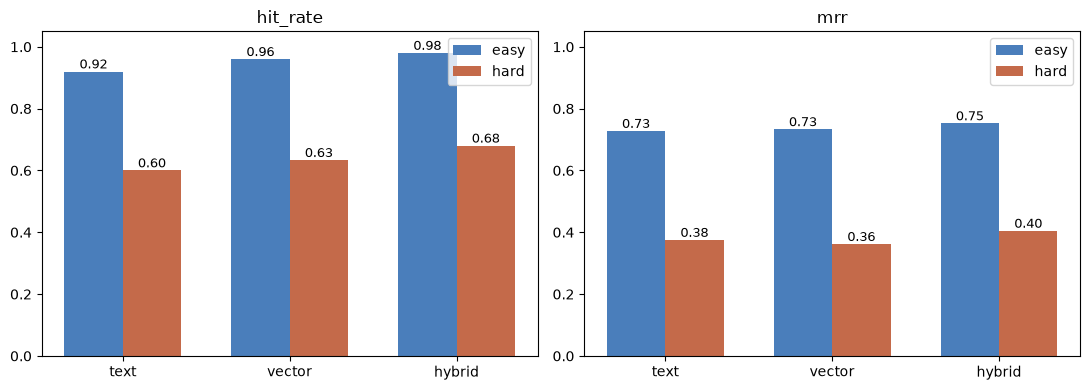

In [64]:
methods = ["text", "vector", "hybrid"]
by = {}
for m, fn in [("text", text_search), ("vector", vector_search), ("hybrid", hybrid_search)]:
    by[m] = {d: evaluate_search(fn, seed[seed.difficulty == d]) for d in ("easy", "hard")}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(methods))
w = 0.35

for ax, metric in ((ax1, "hit_rate"), (ax2, "mrr")):
    easy = [by[m]["easy"][metric] for m in methods]
    hard = [by[m]["hard"][metric] for m in methods]
    ax.bar(x - w/2, easy, w, label="easy", color="#4a7ebb")
    ax.bar(x + w/2, hard, w, label="hard", color="#c46a4a")
    for i, v in enumerate(easy):
        ax.text(i - w/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
    for i, v in enumerate(hard):
        ax.text(i + w/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
    ax.set_xticks(x, methods)
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.tight_layout()
plt.show()

In [68]:
def analyze_search(search_fn, questions, num_results=10):
    """One row per question: where the expected note landed and what
    took its place. The raw material for every diagnosis below."""
    rows = []
    for q in tqdm(questions.itertuples(), total=len(questions)):
        paths = [r["path"] for r in search_fn(q.question, num_results=num_results)]
        rank = paths.index(q.path) + 1 if q.path in paths else None
        rows.append({
            "question": q.question,
            "difficulty": q.difficulty,
            "expected": q.path,
            "rank": rank,
            "hit": rank is not None,
            "got_top1": paths[0] if paths else None,
        })
    return pd.DataFrame(rows)


results = analyze_search(hybrid_search, seed)
results.groupby("difficulty")["hit"].mean()


100%|██████████| 200/200 [00:07<00:00, 28.42it/s]


difficulty
easy    0.98
hard    0.68
Name: hit, dtype: float64

In [70]:
misses = results[~results.hit]

print("== notas mais dificeis de achar (misses por nota esperada) ==")
print(misses.groupby("expected").size().sort_values(ascending=False).head(8))

print("\n== pares de confusao: esperado -> quem roubou o top-1 ==")
print(misses.groupby(["expected", "got_top1"]).size()
      .sort_values(ascending=False).head(8))

print("\n== onde os acertos pousam (rank dos hits) ==")
print(results[results.hit]["rank"].value_counts().sort_index())


misses[misses.difficulty == "hard"][["question", "expected", "got_top1"]].head(10)


== notas mais dificeis de achar (misses por nota esperada) ==
expected
llm-zoomcamp-2026/01-agentic-rag/11-agents-intro.md             3
llm-zoomcamp-2026/01-agentic-rag/10-rag-next-steps.md           3
llm-zoomcamp-2026/01-agentic-rag/12-rag-revision.md             3
llm-zoomcamp-2026/02-vector-search/01-intro-vector-search.md    3
llm-zoomcamp-2026/04-evaluation/04-search-evaluation.md         3
llm-zoomcamp-2026/02-vector-search/05-minsearch-vector.md       2
llm-zoomcamp-2026/01-agentic-rag/15-frameworks.md               2
llm-zoomcamp-2026/04-evaluation/01-intro-evaluation.md          2
dtype: int64

== pares de confusao: esperado -> quem roubou o top-1 ==
expected                                                got_top1                                                    
llm-zoomcamp-2026/01-agentic-rag/10-rag-next-steps.md   llm-zoomcamp-2026/01-agentic-rag/04-dataset.md                  2
llm-zoomcamp-2026/01-agentic-rag/03-rag.md              llm-zoomcamp-2026/01-agentic-rag/16

,question,expected,got_top1
57,if i want to switch to a different ai company ...,llm-zoomcamp-2026/01-agentic-rag/03-rag.md,llm-zoomcamp-2026/01-agentic-rag/16-other-fram...
63,how do i make a hit in the original question c...,llm-zoomcamp-2026/01-agentic-rag/05-search.md,llm-zoomcamp-2026/04-evaluation/06-search-tuni...
65,why does sloppy wording in the template let th...,llm-zoomcamp-2026/01-agentic-rag/06-building-p...,llm-zoomcamp-2026/01-agentic-rag/13-function-c...
68,why do i have to send the entire back and fort...,llm-zoomcamp-2026/01-agentic-rag/07-llm.md,llm-zoomcamp-2026/01-agentic-rag/13-function-c...
69,is there a shortcut to grab the reply text wit...,llm-zoomcamp-2026/01-agentic-rag/07-llm.md,llm-zoomcamp-2026/02-vector-search/07-sqlitese...
73,does the thing doing the lookups have to be a ...,llm-zoomcamp-2026/01-agentic-rag/08-rag-helper.md,llm-zoomcamp-2026/02-vector-search/04-vector-s...
77,why is baking the knowledge straight into the ...,llm-zoomcamp-2026/01-agentic-rag/10-rag-next-s...,llm-zoomcamp-2026/01-agentic-rag/01-intro-agen...
78,how could the smarter version help a student w...,llm-zoomcamp-2026/01-agentic-rag/10-rag-next-s...,llm-zoomcamp-2026/01-agentic-rag/04-dataset.md
79,what did the teacher find when he went through...,llm-zoomcamp-2026/01-agentic-rag/10-rag-next-s...,llm-zoomcamp-2026/01-agentic-rag/04-dataset.md
80,besides spelling mistakes what other situation...,llm-zoomcamp-2026/01-agentic-rag/11-agents-int...,llm-zoomcamp-2026/05-monitoring/02-assistant-s...


# RAG 

In [65]:
class ObsidianRAG:
    """The retrieval chain in the LangChain shape.

    A retriever supplies Documents and the llm answers only from them.
    invoke(question) returns the answer plus the source documents, so
    any interface can show citations without knowing about retrieval.
    """

    INSTRUCTIONS = """
    You are the assistant for a personal Obsidian vault.

    Answer the question using only the provided context, 
    which contains parts of the owner's notes. Each part starts with its source path.

    Be direct and concise. After the answer, list the notes you actually
    used, one per line, in the form:
    Sources:
    - <path>

    If the context does not contain the answer, say you could not find it
    in the vault, and do not invent anything.
    
    You may combine information from multiple excerpts and state what
    follows from them. Only say you could not find it when the context
    contains nothing relevant to the question.

    """.strip()

    PROMPT_TEMPLATE = """
    CONTEXT:
    {context}

    QUESTION: {question}
    """.strip()


    def __init__(self, retriever, llm_client, model):
        self.retriever = retriever
        self.llm_client = llm_client
        self.model = model

    def build_context(self, documents):
        """One block per chunk, opened by its source path so the model
        can cite notes by name."""
        blocks = [f"source: {d.metadata['source']}\n{d.page_content}"
                  for d in documents]
        return "\n\n---\n\n".join(blocks)

    def build_prompt(self, question, documents):
        return self.PROMPT_TEMPLATE.format(
            question=question, context=self.build_context(documents)
        )

    def invoke(self, question):
        documents = self.retriever.get_relevant_documents(question)
        prompt = self.build_prompt(question, documents)

        response = self.llm_client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": self.INSTRUCTIONS},
                {"role": "user", "content": prompt},
            ],
        )

        return {
            "answer": response.choices[0].message.content,
            "source_documents": documents,
            "usage": response.usage,
        }

In [66]:
from openai import OpenAI

ollama = OpenAI(base_url="http://ollama:11434/v1", api_key="ollama")
gpt = OpenAI()
retriever = ElasticsearchRetriever(search_fn=hybrid_search, num_results=10)


rag_gpt = ObsidianRAG(retriever, gpt, model="gpt-5.4-mini")
rag_local = ObsidianRAG(retriever, ollama, model="qwen2.5:7b-instruct")

In [67]:
def compare_models(question):
    """The same chain, model against model."""
    contenders = [
        ("gpt-5.4-mini", rag_gpt),
        ("qwen2.5:7b local", rag_local),
        # ("llama3.2:3b local", ObsidianRAG(retriever, ollama, model="llama3.2:3b")),
    ]
    for name, r in contenders:
        t0 = time.time()
        out = r.invoke(question)
        print("=" * 90)
        print(f"[{name}] {time.time()-t0:.1f}s, {out['usage'].completion_tokens} tokens out")
        print(out["answer"])
        print()

question = "Is necessary to use Docker to install sqlite?"
compare_models(question)

[gpt-5.4-mini] 2.7s, 101 tokens out
No. The notes say SQLite “ships with Python,” so you don’t add any dependency, and for the lightweight project you can use SQLite plus a Streamlit dashboard and even skip Docker entirely. Docker is used later for Postgres/Grafana, not for installing SQLite.

Sources:
- llm-zoomcamp-2026/05-monitoring/07-streamlit-dashboard.md
- llm-zoomcamp-2026/01-agentic-rag/09-data-ingestion.md

[qwen2.5:7b local] 10.7s, 56 tokens out
No, using Docker is not necessary to install SQLite. The project documentation mentions that SQLite ships with Python and doesn't require additional dependencies.

Sources:
- llm-zoomcamp-2026/01-agentic-rag / 09-data-ingestion.md

